In [1]:
from SimplexTree import SimplexTree
from CechComplex import CechComplex
from utils import plot_2d
import numpy as np

In [2]:
def make_n_simplex(n):
    st = SimplexTree(n)
    st.insert(list(range(n)))
    return st


def make_n_sphere(n):
    st = SimplexTree(n + 2)
    vertices = list(range(n + 2))
    for i in range(n + 2):
        st.insert(vertices[:i] + vertices[i + 1 :])
    return st


def make_n_torus(n):
    pass  # TODO

In [3]:
st_simplex = make_n_simplex(4)
for k in range(4, -2, -1):
    print(f"{k}-simpleces:", st_simplex.get_simplices(k))
print("-" * 50)
st_sphere = make_n_sphere(2)
for k in range(4, -2, -1):
    print(f"{k}-simpleces:", st_sphere.get_simplices(k))

4-simpleces: []
3-simpleces: [(0, 1, 2, 3)]
2-simpleces: [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
1-simpleces: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
0-simpleces: [(0,), (1,), (2,), (3,)]
-1-simpleces: []
--------------------------------------------------
4-simpleces: []
3-simpleces: []
2-simpleces: [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
1-simpleces: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
0-simpleces: [(0,), (1,), (2,), (3,)]
-1-simpleces: []


In [4]:
for k in range(4, -1, -1):
    matrix = st_simplex.boundary_matrix(k)
    print(f"{k}-th boundary matrix (shape {matrix.shape}):\n", matrix)

4-th boundary matrix (shape (1, 0)):
 []
3-th boundary matrix (shape (4, 1)):
 [[-1]
 [ 1]
 [-1]
 [ 1]]
2-th boundary matrix (shape (6, 4)):
 [[ 1  1  0  0]
 [-1  0  1  0]
 [ 0 -1 -1  0]
 [ 1  0  0  1]
 [ 0  1  0 -1]
 [ 0  0  1  1]]
1-th boundary matrix (shape (4, 6)):
 [[-1 -1 -1  0  0  0]
 [ 1  0  0 -1 -1  0]
 [ 0  1  0  1  0 -1]
 [ 0  0  1  0  1  1]]
0-th boundary matrix (shape (0, 4)):
 []


In [5]:
st_simplex.boundary_matrices()

[array([[-1, -1, -1,  0,  0,  0],
        [ 1,  0,  0, -1, -1,  0],
        [ 0,  1,  0,  1,  0, -1],
        [ 0,  0,  1,  0,  1,  1]]),
 array([[ 1,  1,  0,  0],
        [-1,  0,  1,  0],
        [ 0, -1, -1,  0],
        [ 1,  0,  0,  1],
        [ 0,  1,  0, -1],
        [ 0,  0,  1,  1]]),
 array([[-1],
        [ 1],
        [-1],
        [ 1]])]

In [7]:
for k in range(4, -2, -1):
    print(
        f"dim C_{k}: {st_simplex.chain_dim(k)}\tdim B_{k}: {st_simplex.boundary_dim(k)}\tdim Z_{k}: {st_simplex.cycle_dim(k)}\tdim H_{k}: {st_simplex.betti(k)}"
    )
print(st_simplex.chain_dims())
print(st_simplex.boundary_dims())
print(st_simplex.cycle_dims())
print(st_simplex.bettis())
print("-" * 50)
for k in range(4, -2, -1):
    print(
        f"dim C_{k}: {st_sphere.chain_dim(k)}\tdim B_{k}: {st_sphere.boundary_dim(k)}\tdim Z_{k}: {st_sphere.cycle_dim(k)}\tdim H_{k}: {st_sphere.betti(k)}"
    )
print(st_sphere.chain_dims())
print(st_sphere.boundary_dims())
print(st_sphere.cycle_dims())
print(st_sphere.bettis())

dim C_4: 0	dim B_4: 0	dim Z_4: 0	dim H_4: 0
dim C_3: 1	dim B_3: 0	dim Z_3: 0	dim H_3: 0
dim C_2: 4	dim B_2: 1	dim Z_2: 1	dim H_2: 0
dim C_1: 6	dim B_1: 3	dim Z_1: 3	dim H_1: 0
dim C_0: 4	dim B_0: 3	dim Z_0: 4	dim H_0: 1
dim C_-1: 0	dim B_-1: 0	dim Z_-1: 0	dim H_-1: 0
[4, 6, 4, 1]
[3, 3, 1, 0]
[4, 3, 1, 0]
[1, 0, 0, 0]
--------------------------------------------------
dim C_4: 0	dim B_4: 0	dim Z_4: 0	dim H_4: 0
dim C_3: 0	dim B_3: 0	dim Z_3: 0	dim H_3: 0
dim C_2: 4	dim B_2: 0	dim Z_2: 1	dim H_2: 1
dim C_1: 6	dim B_1: 3	dim Z_1: 3	dim H_1: 0
dim C_0: 4	dim B_0: 3	dim Z_0: 4	dim H_0: 1
dim C_-1: 0	dim B_-1: 0	dim Z_-1: 0	dim H_-1: 0
[4, 6, 4, 0]
[3, 3, 0, 0]
[4, 3, 1, 0]
[1, 0, 1, 0]


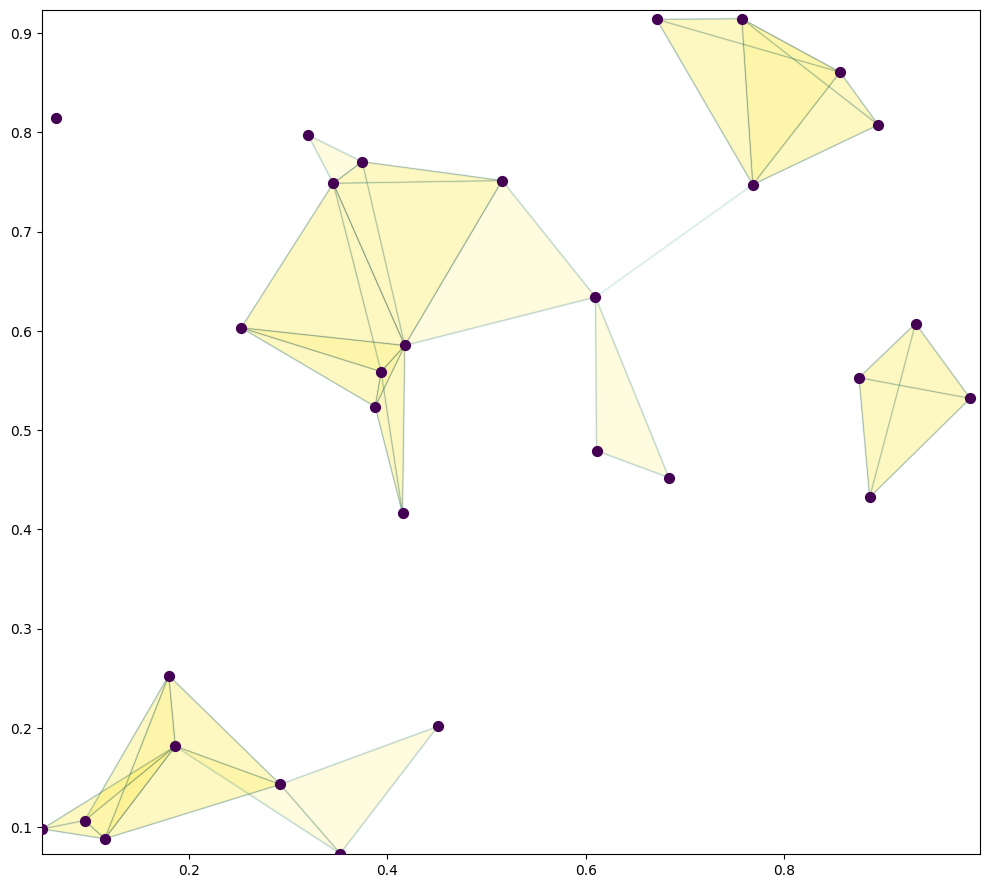

In [20]:
points = np.random.rand(30, 2)
cc = CechComplex(points, 0.2)
st = cc.create_complex(2)
plot_2d(st, points)